# Model Comparison — Multivariate Time-Series Forecasting

## Objective

This stage compares the forecasting models developed in the previous phases using their finalized validation results.

The comparison includes:

- Naive Baseline
- Seasonal Naive Baseline
- 28-day Moving Average
- RNN
- LSTM
- GRU
- LSTM + Attention
- Transformer

## Evaluation Metrics

The models are compared using:

- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- WAPE (Weighted Absolute Percentage Error)

Lower values indicate lower validation error for each metric.

## Validation Period

2016-03-28 to 2016-04-24

All model results correspond to the same validation period and forecasting setup used in the previous stages.

In [1]:
import pandas as pd
import numpy as np

results = pd.DataFrame({
    "Model": [
        "Naive",
        "Seasonal Naive",
        "28-day Moving Average",
        "RNN",
        "LSTM",
        "GRU",
        "LSTM + Attention",
        "Transformer"
    ],

    "MAE": [
        1.1798,
        1.2054,
        1.0050,
        1.0326,
        1.0220,
        1.0691,
        1.0058,
        1.0217
    ],

    "RMSE": [
        2.5948,
        2.6601,
        2.0935,
        2.4927,
        2.3766,
        2.5656,
        2.2867,
        2.5463
    ],

    "WAPE": [
        85.0972,
        86.9390,
        72.4875,
        74.4774,
        73.7131,
        77.1137,
        72.5478,
        73.6934
    ]
})

results

,Model,MAE,RMSE,WAPE
0,Naive,1.1798,2.5948,85.0972
1,Seasonal Naive,1.2054,2.6601,86.9390
2,28-day Moving Average,1.0050,2.0935,72.4875
3,RNN,1.0326,2.4927,74.4774
4,LSTM,1.0220,2.3766,73.7131
5,GRU,1.0691,2.5656,77.1137
6,LSTM + Attention,1.0058,2.2867,72.5478
7,Transformer,1.0217,2.5463,73.6934


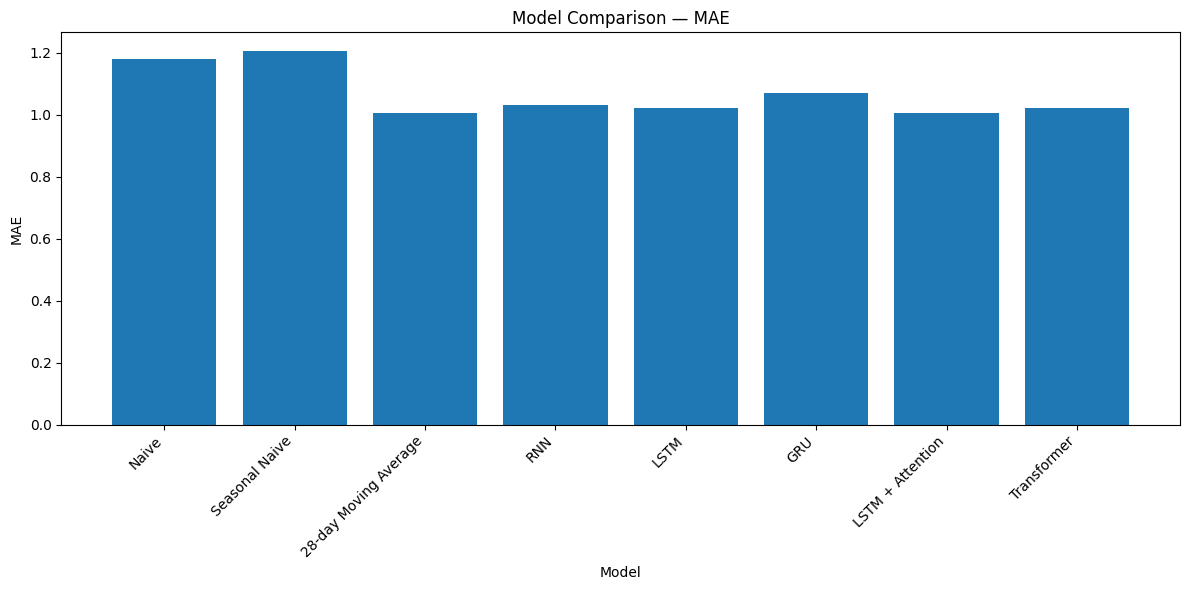

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.bar(results["Model"], results["MAE"])

plt.xlabel("Model")
plt.ylabel("MAE")
plt.title("Model Comparison — MAE")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

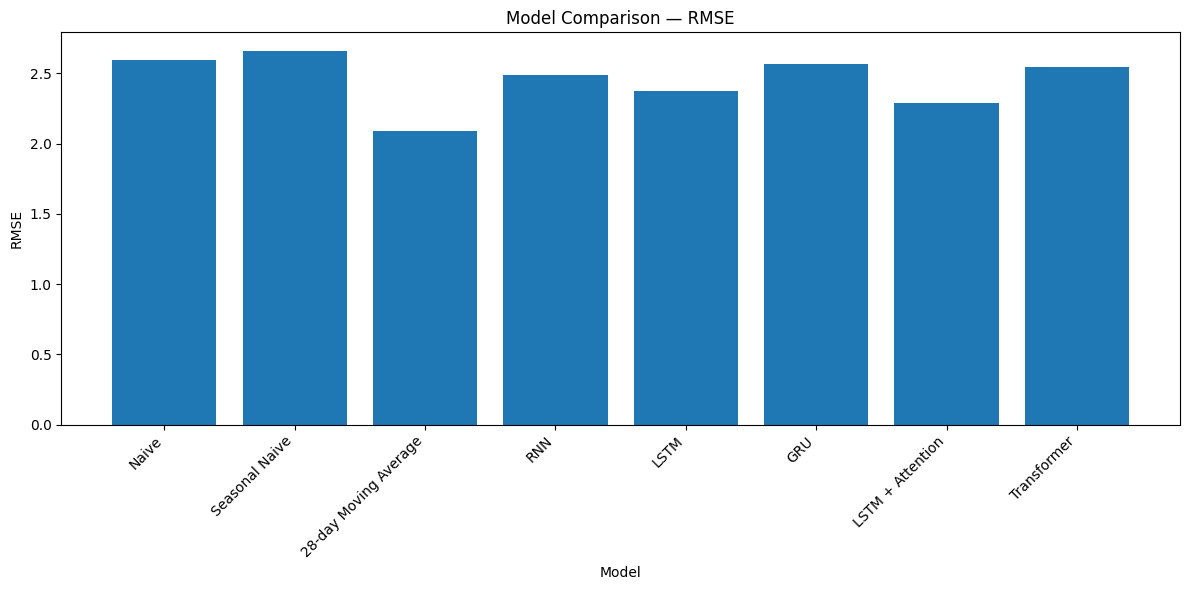

In [3]:
plt.figure(figsize=(12, 6))

plt.bar(results["Model"], results["RMSE"])

plt.xlabel("Model")
plt.ylabel("RMSE")
plt.title("Model Comparison — RMSE")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

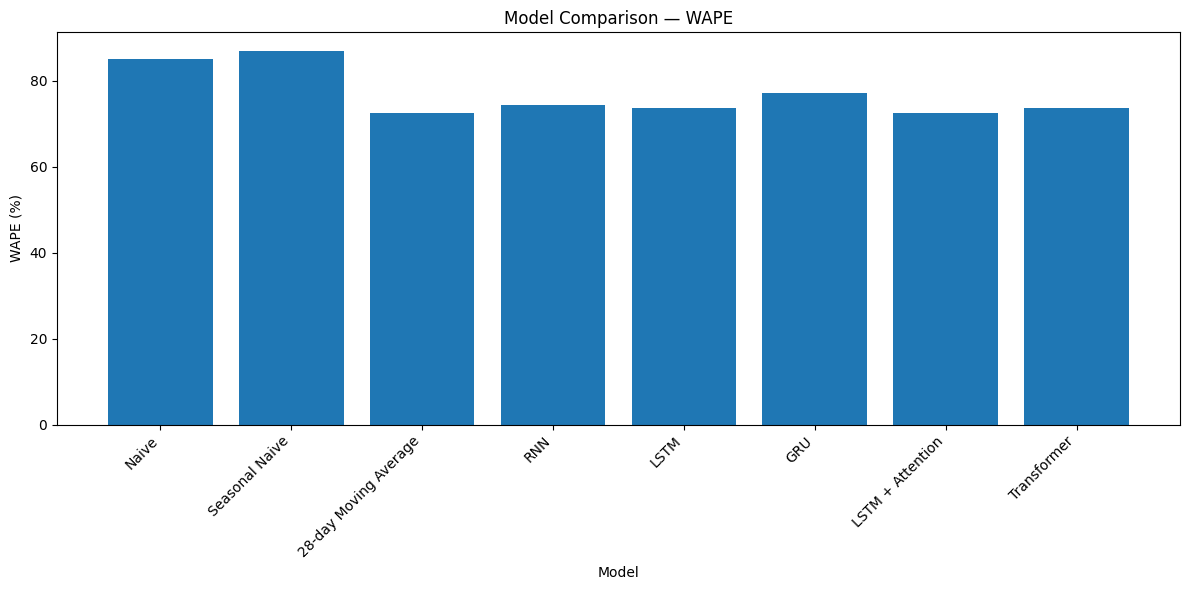

In [4]:
plt.figure(figsize=(12, 6))

plt.bar(results["Model"], results["WAPE"])

plt.xlabel("Model")
plt.ylabel("WAPE (%)")
plt.title("Model Comparison — WAPE")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [5]:
# Calculate percentage improvement over the Naive baseline

naive_mae = results.loc[results["Model"] == "Naive", "MAE"].iloc[0]
naive_rmse = results.loc[results["Model"] == "Naive", "RMSE"].iloc[0]
naive_wape = results.loc[results["Model"] == "Naive", "WAPE"].iloc[0]

comparison = results.copy()

comparison["MAE_Improvement_%"] = (
    (naive_mae - comparison["MAE"]) / naive_mae
) * 100

comparison["RMSE_Improvement_%"] = (
    (naive_rmse - comparison["RMSE"]) / naive_rmse
) * 100

comparison["WAPE_Improvement_%"] = (
    (naive_wape - comparison["WAPE"]) / naive_wape
) * 100

comparison

,Model,MAE,RMSE,WAPE,MAE_Improvement_%,RMSE_Improvement_%,WAPE_Improvement_%
0,Naive,1.1798,2.5948,85.0972,0.000000,0.000000,0.000000
1,Seasonal Naive,1.2054,2.6601,86.9390,-2.169859,-2.516572,-2.164349
2,28-day Moving Average,1.0050,2.0935,72.4875,14.816071,19.319408,14.817996
3,RNN,1.0326,2.4927,74.4774,12.476691,3.934793,12.479612
4,LSTM,1.0220,2.3766,73.7131,13.375148,8.409126,13.377761
5,GRU,1.0691,2.5656,77.1137,9.382946,1.125328,9.381625
6,LSTM + Attention,1.0058,2.2867,72.5478,14.748262,11.873747,14.747136
7,Transformer,1.0217,2.5463,73.6934,13.400576,1.869123,13.400911


In [6]:
comparison["Category"] = comparison["Model"].map({
    "Naive": "Baseline",
    "Seasonal Naive": "Baseline",
    "28-day Moving Average": "Baseline",
    "RNN": "Recurrent Deep Learning",
    "LSTM": "Recurrent Deep Learning",
    "GRU": "Recurrent Deep Learning",
    "LSTM + Attention": "Attention-based",
    "Transformer": "Attention-based"
})

comparison[
    [
        "Model",
        "Category",
        "MAE",
        "RMSE",
        "WAPE",
        "MAE_Improvement_%",
        "RMSE_Improvement_%",
        "WAPE_Improvement_%"
    ]
]

,Model,Category,MAE,RMSE,WAPE,MAE_Improvement_%,RMSE_Improvement_%,WAPE_Improvement_%
0,Naive,Baseline,1.1798,2.5948,85.0972,0.000000,0.000000,0.000000
1,Seasonal Naive,Baseline,1.2054,2.6601,86.9390,-2.169859,-2.516572,-2.164349
2,28-day Moving Average,Baseline,1.0050,2.0935,72.4875,14.816071,19.319408,14.817996
3,RNN,Recurrent Deep Learning,1.0326,2.4927,74.4774,12.476691,3.934793,12.479612
4,LSTM,Recurrent Deep Learning,1.0220,2.3766,73.7131,13.375148,8.409126,13.377761
5,GRU,Recurrent Deep Learning,1.0691,2.5656,77.1137,9.382946,1.125328,9.381625
6,LSTM + Attention,Attention-based,1.0058,2.2867,72.5478,14.748262,11.873747,14.747136
7,Transformer,Attention-based,1.0217,2.5463,73.6934,13.400576,1.869123,13.400911


In [7]:
# Compare every model against the 28-day Moving Average baseline

mae_baseline = results.loc[
    results["Model"] == "28-day Moving Average", "MAE"
].iloc[0]

rmse_baseline = results.loc[
    results["Model"] == "28-day Moving Average", "RMSE"
].iloc[0]

wape_baseline = results.loc[
    results["Model"] == "28-day Moving Average", "WAPE"
].iloc[0]

comparison["MAE_Gap_vs_28D_MA"] = comparison["MAE"] - mae_baseline
comparison["RMSE_Gap_vs_28D_MA"] = comparison["RMSE"] - rmse_baseline
comparison["WAPE_Gap_vs_28D_MA"] = comparison["WAPE"] - wape_baseline

comparison[
    [
        "Model",
        "Category",
        "MAE",
        "MAE_Gap_vs_28D_MA",
        "RMSE",
        "RMSE_Gap_vs_28D_MA",
        "WAPE",
        "WAPE_Gap_vs_28D_MA"
    ]
]

,Model,Category,MAE,MAE_Gap_vs_28D_MA,RMSE,RMSE_Gap_vs_28D_MA,WAPE,WAPE_Gap_vs_28D_MA
0,Naive,Baseline,1.1798,0.1748,2.5948,0.5013,85.0972,12.6097
1,Seasonal Naive,Baseline,1.2054,0.2004,2.6601,0.5666,86.9390,14.4515
2,28-day Moving Average,Baseline,1.0050,0.0000,2.0935,0.0000,72.4875,0.0000
3,RNN,Recurrent Deep Learning,1.0326,0.0276,2.4927,0.3992,74.4774,1.9899
4,LSTM,Recurrent Deep Learning,1.0220,0.0170,2.3766,0.2831,73.7131,1.2256
5,GRU,Recurrent Deep Learning,1.0691,0.0641,2.5656,0.4721,77.1137,4.6262
6,LSTM + Attention,Attention-based,1.0058,0.0008,2.2867,0.1932,72.5478,0.0603
7,Transformer,Attention-based,1.0217,0.0167,2.5463,0.4528,73.6934,1.2059


In [9]:
# Calculate relative percentage difference from the 28-day Moving Average

mae_baseline = results.loc[
    results["Model"] == "28-day Moving Average", "MAE"
].iloc[0]

rmse_baseline = results.loc[
    results["Model"] == "28-day Moving Average", "RMSE"
].iloc[0]

wape_baseline = results.loc[
    results["Model"] == "28-day Moving Average", "WAPE"
].iloc[0]


# Start from comparison so that Category is already available
final_comparison = comparison.copy()

final_comparison["MAE_Difference_%"] = (
    (final_comparison["MAE"] - mae_baseline)
    / mae_baseline
) * 100

final_comparison["RMSE_Difference_%"] = (
    (final_comparison["RMSE"] - rmse_baseline)
    / rmse_baseline
) * 100

final_comparison["WAPE_Difference_%"] = (
    (final_comparison["WAPE"] - wape_baseline)
    / wape_baseline
) * 100


final_comparison[
    [
        "Model",
        "Category",
        "MAE",
        "MAE_Difference_%",
        "RMSE",
        "RMSE_Difference_%",
        "WAPE",
        "WAPE_Difference_%"
    ]
]

,Model,Category,MAE,MAE_Difference_%,RMSE,RMSE_Difference_%,WAPE,WAPE_Difference_%
0,Naive,Baseline,1.1798,17.393035,2.5948,23.945546,85.0972,17.395689
1,Seasonal Naive,Baseline,1.2054,19.940299,2.6601,27.064724,86.9390,19.936541
2,28-day Moving Average,Baseline,1.0050,0.000000,2.0935,0.000000,72.4875,0.000000
3,RNN,Recurrent Deep Learning,1.0326,2.746269,2.4927,19.068545,74.4774,2.745163
4,LSTM,Recurrent Deep Learning,1.0220,1.691542,2.3766,13.522809,73.7131,1.690774
5,GRU,Recurrent Deep Learning,1.0691,6.378109,2.5656,22.550752,77.1137,6.382066
6,LSTM + Attention,Attention-based,1.0058,0.079602,2.2867,9.228565,72.5478,0.083187
7,Transformer,Attention-based,1.0217,1.661692,2.5463,21.628851,73.6934,1.663597


In [10]:
final_table = results.copy()

final_table["Model Type"] = final_table["Model"].map({
    "Naive": "Baseline",
    "Seasonal Naive": "Baseline",
    "28-day Moving Average": "Baseline",
    "RNN": "Recurrent Deep Learning",
    "LSTM": "Recurrent Deep Learning",
    "GRU": "Recurrent Deep Learning",
    "LSTM + Attention": "Attention-based",
    "Transformer": "Attention-based"
})

final_table = final_table[
    ["Model", "Model Type", "MAE", "RMSE", "WAPE"]
]

final_table

,Model,Model Type,MAE,RMSE,WAPE
0,Naive,Baseline,1.1798,2.5948,85.0972
1,Seasonal Naive,Baseline,1.2054,2.6601,86.9390
2,28-day Moving Average,Baseline,1.0050,2.0935,72.4875
3,RNN,Recurrent Deep Learning,1.0326,2.4927,74.4774
4,LSTM,Recurrent Deep Learning,1.0220,2.3766,73.7131
5,GRU,Recurrent Deep Learning,1.0691,2.5656,77.1137
6,LSTM + Attention,Attention-based,1.0058,2.2867,72.5478
7,Transformer,Attention-based,1.0217,2.5463,73.6934


# Model Comparison — Final Results

## Objective

This stage compares all forecasting approaches developed in the previous phases using the same validation period and evaluation metrics.

The comparison includes:

- Naive Baseline
- Seasonal Naive Baseline
- 28-day Moving Average
- RNN
- LSTM
- GRU
- LSTM + Attention
- Transformer

## Experimental Setup

- Validation Period: 2016-03-28 to 2016-04-24
- Validation Observations: 853,720
- Forecast Horizon: 1 day
- Sequence Length for Deep Learning Models: 28 days
- Input Features: 22
- Target: `sales`

## Evaluation Metrics

- MAE: Mean Absolute Error
- RMSE: Root Mean Squared Error
- WAPE: Weighted Absolute Percentage Error

Lower values indicate lower validation error.

## Final Comparison

| Model | Model Type | MAE | RMSE | WAPE |
|---|---|---:|---:|---:|
| Naive | Baseline | 1.1798 | 2.5948 | 85.0972% |
| Seasonal Naive | Baseline | 1.2054 | 2.6601 | 86.9390% |
| 28-day Moving Average | Baseline | 1.0050 | 2.0935 | 72.4875% |
| RNN | Recurrent Deep Learning | 1.0326 | 2.4927 | 74.4774% |
| LSTM | Recurrent Deep Learning | 1.0220 | 2.3766 | 73.7131% |
| GRU | Recurrent Deep Learning | 1.0691 | 2.5656 | 77.1137% |
| LSTM + Attention | Attention-based | 1.0058 | 2.2867 | 72.5478% |
| Transformer | Attention-based | 1.0217 | 2.5463 | 73.6934% |

## Comparison with Naive Baseline

Relative improvement over the Naive baseline:

| Model | MAE Improvement | RMSE Improvement | WAPE Improvement |
|---|---:|---:|---:|
| Naive | 0.00% | 0.00% | 0.00% |
| Seasonal Naive | -2.17% | -2.52% | -2.16% |
| 28-day Moving Average | 14.82% | 19.32% | 14.82% |
| RNN | 12.48% | 3.93% | 12.48% |
| LSTM | 13.38% | 8.41% | 13.38% |
| GRU | 9.38% | 1.13% | 9.38% |
| LSTM + Attention | 14.75% | 11.87% | 14.75% |
| Transformer | 13.40% | 1.87% | 13.40% |

## Comparison with 28-day Moving Average

The 28-day Moving Average provides a strong reference point for evaluating the deep learning models.

| Model | MAE Difference | RMSE Difference | WAPE Difference |
|---|---:|---:|---:|
| Naive | +17.39% | +23.95% | +17.40% |
| Seasonal Naive | +19.94% | +27.06% | +19.94% |
| 28-day Moving Average | 0.00% | 0.00% | 0.00% |
| RNN | +2.75% | +19.07% | +2.75% |
| LSTM | +1.69% | +13.52% | +1.69% |
| GRU | +6.38% | +22.55% | +6.38% |
| LSTM + Attention | +0.08% | +9.23% | +0.08% |
| Transformer | +1.66% | +21.63% | +1.66% |

## Key Findings

### 1. Strong performance of the simple baseline

The 28-day Moving Average achieved:

- MAE: 1.0050
- RMSE: 2.0935
- WAPE: 72.4875%

It produced the lowest validation error among the evaluated models in this experiment.

### 2. LSTM + Attention was very close in MAE and WAPE

LSTM + Attention achieved:

- MAE: 1.0058
- RMSE: 2.2867
- WAPE: 72.5478%

Its MAE was only 0.08% higher than the 28-day Moving Average and its WAPE was only 0.08% higher.

However, its RMSE was 9.23% higher relative to the 28-day Moving Average.

### 3. Recurrent models improved over simple Naive forecasting

RNN, LSTM, and GRU all produced lower MAE and WAPE than the Naive baseline.

LSTM also achieved a lower RMSE than RNN and GRU in this experiment.

### 4. Attention mechanisms provided competitive results

LSTM + Attention achieved lower validation errors than the standard LSTM across MAE, RMSE, and WAPE.

The Transformer also improved over the Naive baseline, although its RMSE remained higher than the LSTM and LSTM + Attention models.

### 5. Model complexity did not automatically produce lower validation error

The results show that increasing architectural complexity does not automatically guarantee lower forecasting error.

A simple 28-day historical average remained highly competitive against the deep learning and attention-based architectures.

## Overall Conclusion

The experiments demonstrate that both statistical baselines and deep learning architectures can provide useful forecasting approaches for the M5-style retail sales dataset.

The 28-day Moving Average provided a strong benchmark, while LSTM + Attention achieved very similar MAE and WAPE with a more complex learned architecture.

These results will be used as the foundation for the subsequent inventory management and optimization stages.

## Stage Status

**Phase 10 — Model Comparison: COMPLETE**